# Deliverable 3
By:


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay, recall_score, precision_score, roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import shap
from lime import lime_tabular
from codecarbon import EmissionsTracker
import joblib
import xgboost as xgb
from sklearn.preprocessing import RobustScaler, StandardScaler

c:\Users\ethan\OneDrive\Documents\Strathmore\CESI\deep_learning\Group_work\deep-learning-diabete-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading the Dataset & Feature Engineering

In [2]:
df = pd.read_csv('..\\datasets\\diabetes_012_health_indicators_BRFSS2015.csv')

# Remove duplicates and handle missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Create binary target variable
df["Diabetes_binary"] = df["Diabetes_012"].map({0.0: 0, 1.0: 0, 2.0: 1})
df.drop(columns=["Diabetes_012"], inplace=True)

In [3]:
correlations = df.corr()["Diabetes_binary"].abs().sort_values(ascending=False)
correlations = correlations[1:]  # Get rid of the target variable itself
print(correlations)

GenHlth                 0.277060
HighBP                  0.254029
DiffWalk                0.205511
BMI                     0.205125
HighChol                0.194683
Age                     0.176953
HeartDiseaseorAttack    0.168336
PhysHlth                0.156446
Income                  0.140934
Education               0.102969
PhysActivity            0.100663
Stroke                  0.099301
CholCheck               0.072396
HvyAlcoholConsump       0.065795
MentHlth                0.054385
Smoker                  0.045588
Veggies                 0.041956
Sex                     0.032574
AnyHealthcare           0.025206
Fruits                  0.025043
NoDocbcCost             0.020206
Name: Diabetes_binary, dtype: float64


In [4]:
# Select top features based on correlation with the target variable
top_features = [feat for feat in correlations.index if correlations[feat] > 0.1]  # Select features with correlation > 0.1
df = df[top_features + ['Diabetes_binary']]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229781 entries, 0 to 253679
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   GenHlth               229781 non-null  float64
 1   HighBP                229781 non-null  float64
 2   DiffWalk              229781 non-null  float64
 3   BMI                   229781 non-null  float64
 4   HighChol              229781 non-null  float64
 5   Age                   229781 non-null  float64
 6   HeartDiseaseorAttack  229781 non-null  float64
 7   PhysHlth              229781 non-null  float64
 8   Income                229781 non-null  float64
 9   Education             229781 non-null  float64
 10  PhysActivity          229781 non-null  float64
 11  Diabetes_binary       229781 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 22.8 MB


In [5]:
# Scale features using StandardScaler
scaler = StandardScaler()
df[top_features] = scaler.fit_transform(df[top_features])

# Save the scaler for later use in the API
joblib.dump(scaler, '..\\models\\scaler.joblib')

['..\\models\\scaler.joblib']

In [6]:
# Balance the dataset using undersampling
class_0 = df[df['Diabetes_binary'] == 0]
class_1 = df[df['Diabetes_binary'] == 1]

class_0_under = class_0.sample(len(class_1), random_state=42)
df_balanced = pd.concat([class_0_under, class_1])
df = df_balanced

print(df.groupby(['Diabetes_binary']).size())

# Prepare features and target variable
X = df[top_features]
y = df['Diabetes_binary']

Diabetes_binary
0    35097
1    35097
dtype: int64


## Train Test Split, Datasets & DataLoaders

In [7]:
# split the data into training and testing sets
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [8]:
# Save the training data and feature names for later use in the API
joblib.dump((X_train, y_train, top_features), '..\\models\\training_data_and_features.joblib')

['..\\models\\training_data_and_features.joblib']

## Shared Pytorh Utilities

In [9]:
# Set Pytorch random seed for reproducibility
torch.manual_seed(42)

In [10]:
class PatientDataset(Dataset):
    def __init__(self, X, y):
        self.num_data = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.num_data[idx], self.y[idx]

In [11]:
train_ds = PatientDataset(X_train, pd.Series(y_train))
val_ds = PatientDataset(X_val, pd.Series(y_val))
test_ds = PatientDataset(X_test, pd.Series(y_test))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [12]:
loss_fn = nn.BCELoss()

In [13]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [14]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    epoch_loss = 0
    accuracy = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        epoch_loss += loss.item()
        
        # Calculate accuracy
        predicted_labels = (pred >= 0.5).float()
        accuracy += (predicted_labels == y).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    epoch_loss /= len(dataloader)
    accuracy /= size
    return epoch_loss, accuracy

In [15]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float() 
            y = y.unsqueeze(1) 
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += ((pred > 0.5) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

In [16]:
epochs = 50

## Simple MLP

### Build the Model

In [18]:
# Define model
class Simple(nn.Module):
    def __init__(self, input_size=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers_stack = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers_stack(x)
        return logits
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            x = self.flatten(x)
            logits = self.layers_stack(x)
            return logits


In [19]:
simple_model = Simple(input_size=len(top_features)).to(device)
print(simple_model)

Simple(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers_stack): Sequential(
    (0): Linear(in_features=11, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [20]:
optimizer = torch.optim.SGD(simple_model.parameters(), lr=1e-3)

### Model Training

In [21]:
loss_history = []
test_loss_history = []
test_accuracy_history = []

tracker = EmissionsTracker()
tracker.start()

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    epoch_loss = train(train_loader, simple_model, loss_fn, optimizer)
    loss_history.append(epoch_loss)
    test_loss, test_accuracy = test(test_loader, simple_model, loss_fn)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)
    
simple_emissions = tracker.stop()
print(f"Carbon footprint of training the model: {simple_emissions} kg CO2")


[codecarbon WARNING @ 12:25:07] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 12:25:09] [setup] RAM Tracking...
[codecarbon INFO @ 12:25:09] [setup] CPU Tracking...
[codecarbon WARNING @ 12:25:11] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 12:25:11] CPU Model on constant consumption mode: AMD Ryzen 5 5625U with Radeon Graphics
[codecarbon WARNING @ 12:25:11] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 12:25:11] [setup] GPU Tracking...
[codecarbon INFO @ 12:25:11] No GPU found.
[codecarbon INFO @ 12:25:11] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 12:25:11] >>> Tracker's metadata:
[codecarbon INFO

Epoch 1
-------------------------------
loss: 0.693287  [   32/28077]
loss: 0.735539  [ 3232/28077]
loss: 0.690129  [ 6432/28077]
loss: 0.671771  [ 9632/28077]
loss: 0.751320  [12832/28077]
loss: 0.761716  [16032/28077]
loss: 0.715041  [19232/28077]
loss: 0.718588  [22432/28077]
loss: 0.756318  [25632/28077]
Test Error: 
 Accuracy: 50.0%, Avg loss: 0.704346 

Epoch 2
-------------------------------
loss: 0.662260  [   32/28077]
loss: 0.714878  [ 3232/28077]
loss: 0.735509  [ 6432/28077]
loss: 0.672599  [ 9632/28077]
loss: 0.732533  [12832/28077]
loss: 0.717865  [16032/28077]
loss: 0.689658  [19232/28077]
loss: 0.696801  [22432/28077]
loss: 0.686762  [25632/28077]
Test Error: 
 Accuracy: 50.0%, Avg loss: 0.695412 

Epoch 3
-------------------------------
loss: 0.696478  [   32/28077]
loss: 0.712927  [ 3232/28077]
loss: 0.675392  [ 6432/28077]
loss: 0.672188  [ 9632/28077]
loss: 0.667175  [12832/28077]
loss: 0.690784  [16032/28077]
loss: 0.698819  [19232/28077]
loss: 0.677649  [22432/280

[codecarbon INFO @ 12:25:32] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W


loss: 0.692172  [ 6432/28077]
loss: 0.680297  [ 9632/28077]


[codecarbon INFO @ 12:25:32] Delta energy consumed for CPU with cpu_load : 0.000038 kWh, power : 8.451407409 W
[codecarbon INFO @ 12:25:32] Energy consumed for All CPU : 0.000038 kWh
[codecarbon INFO @ 12:25:32] 0.000082 kWh of electricity and 0.000000 L of water were used since the beginning.


...

Test Error: 
 Accuracy: 72.7%, Avg loss: 0.554314 

Epoch 46
-------------------------------
loss: 0.641083  [   32/28077]
loss: 0.496894  [ 3232/28077]
loss: 0.650838  [ 6432/28077]
loss: 0.579952  [ 9632/28077]
loss: 0.585824  [12832/28077]
loss: 0.515857  [16032/28077]
loss: 0.480379  [19232/28077]
loss: 0.604245  [22432/28077]
loss: 0.564464  [25632/28077]
Test Error: 
 Accuracy: 72.8%, Avg loss: 0.553596 

Epoch 47
-------------------------------
loss: 0.519352  [   32/28077]
loss: 0.540771  [ 3232/28077]
loss: 0.399878  [ 6432/28077]
loss: 0.619995  [ 9632/28077]
loss: 0.533667  [12832/28077]
loss: 0.511877  [16032/28077]
loss: 0.520691  [19232/28077]
loss: 0.550947  [22432/28077]
loss: 0.524693  [25632/28077]
Test Error: 
 Accuracy: 72.8%, Avg loss: 0.552960 

Epoch 48
-------------------------------
loss: 0.543806  [   32/28077]
loss: 0.720721  [ 3232/28077]
loss: 0.541029  [ 6432/28077]
loss: 0.539027  [ 9632/28077]
loss: 0.507724  [12832/28077]
loss: 0.502365  [16032/28077]
l

[codecarbon INFO @ 12:26:56] Energy consumed for RAM : 0.000271 kWh. RAM Power : 10.0 W


Test Error: 
 Accuracy: 72.7%, Avg loss: 0.551352 



[codecarbon INFO @ 12:26:57] Delta energy consumed for CPU with cpu_load : 0.000010 kWh, power : 3.8234586939 W
[codecarbon INFO @ 12:26:57] Energy consumed for All CPU : 0.000154 kWh
[codecarbon INFO @ 12:26:57] 0.000425 kWh of electricity and 0.000000 L of water were used since the beginning.


Carbon footprint of training the model: 2.3841389427405752e-05 kg CO2


### Model Evaluation

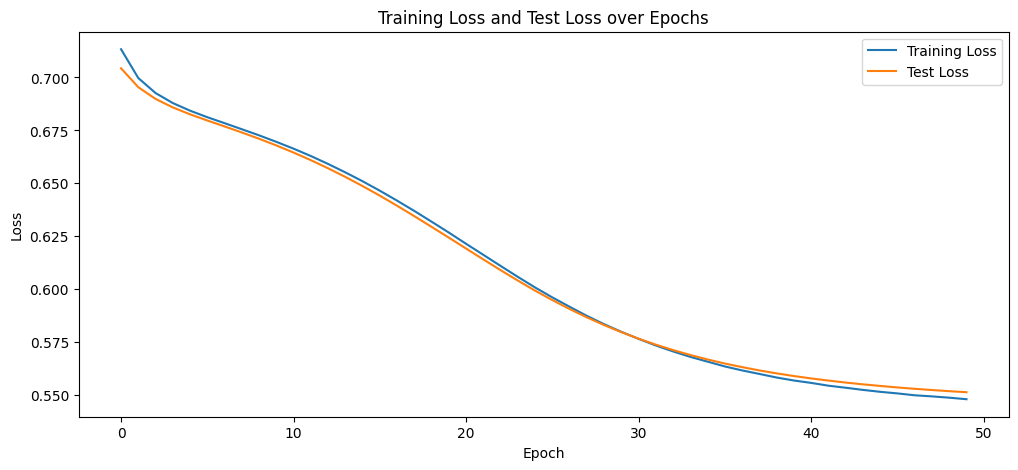

In [22]:
# Plotting the training loss and test loss history on the same graph
plt.figure(figsize=(12, 5))
plt.plot(loss_history, label='Training Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss and Test Loss over Epochs')
plt.legend()
plt.show()


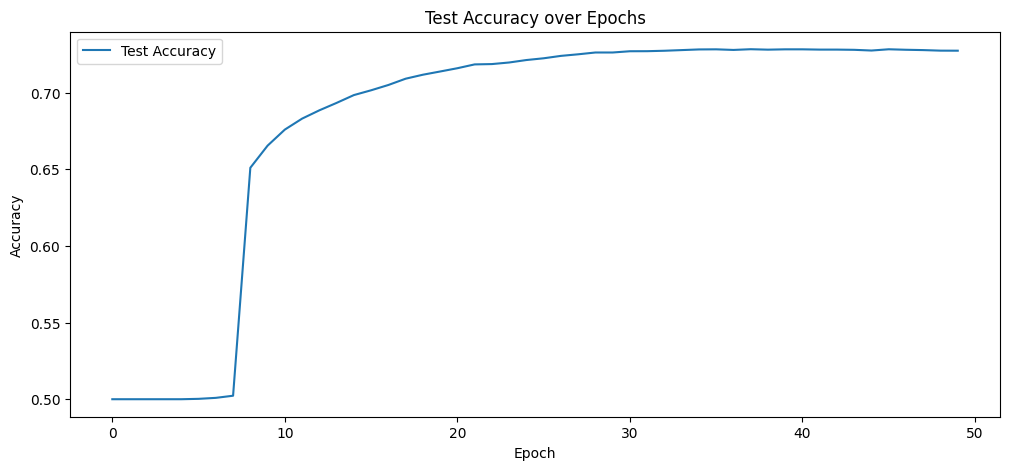

In [23]:
# plotting the test accuracy history
plt.figure(figsize=(12, 5))
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs')
plt.legend()
plt.show()


In [24]:
# Classification report and confusion matrix
simple_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = simple_model(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > 0.5).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

         0.0       0.75      0.69      0.72     14039
         1.0       0.71      0.77      0.74     14039

    accuracy                           0.73     28078
   macro avg       0.73      0.73      0.73     28078
weighted avg       0.73      0.73      0.73     28078



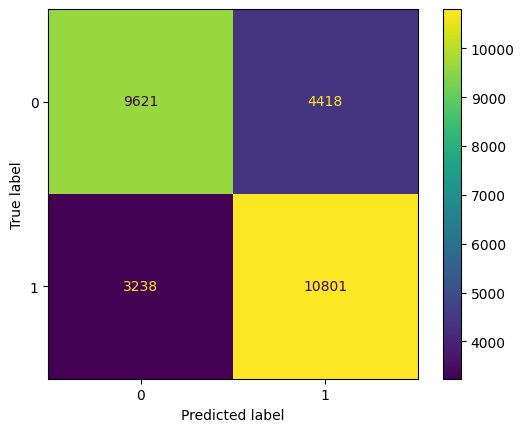

In [25]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Threshold Analysis

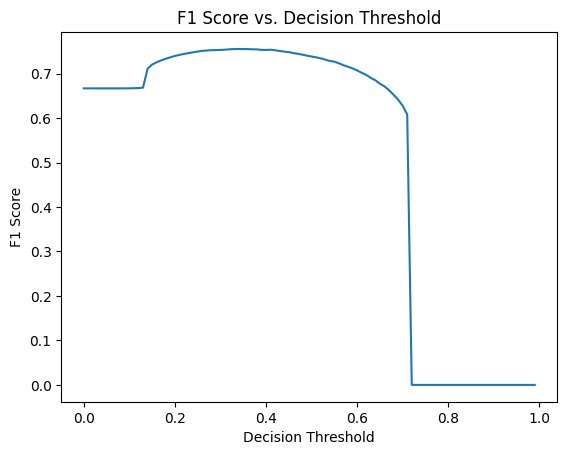

In [26]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [27]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_index]
print(f"Optimal Threshold: {optimal_threshold:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}")

Optimal Threshold: 0.34 with F1 Score: 0.7554


In [28]:
# Classification report and confusion matrix
simple_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = simple_model(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > optimal_threshold).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.54      0.66     14039
         1.0       0.66      0.88      0.76     14039

    accuracy                           0.71     28078
   macro avg       0.74      0.71      0.71     28078
weighted avg       0.74      0.71      0.71     28078



### ExAI

#### SHAP

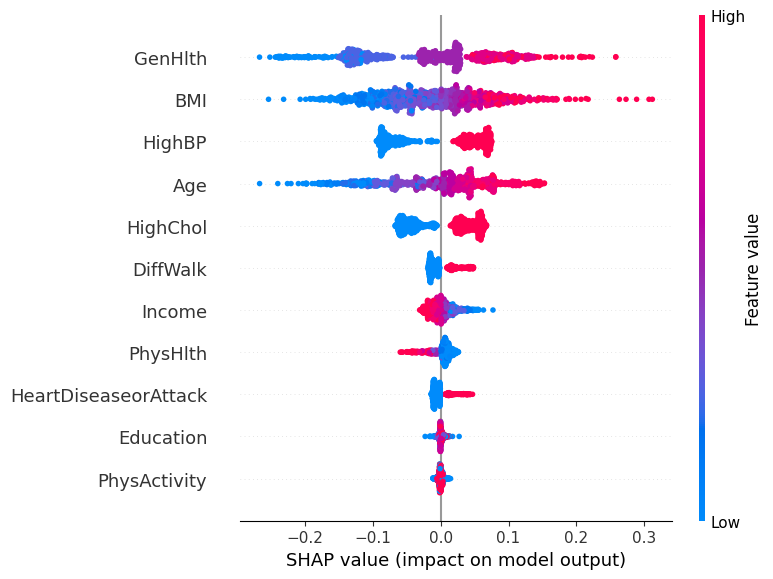

In [29]:
# Ensure background dataset matches the training data
background = X_train.sample(100).to_numpy()
background = torch.tensor(background, dtype=torch.float32).to(device)

# Ensure test samples match the model input
test_samples = torch.tensor(X_test.iloc[:1000].to_numpy(), dtype=torch.float32).to(device)
test_samples_np = test_samples.cpu().numpy()

# Initialize SHAP explainer
e = shap.DeepExplainer(simple_model, background)

# Compute SHAP values
shap_values = e.shap_values(test_samples)

# --- FIX: Normalize shap_values to a 2D array ---
if isinstance(shap_values, list):
    # Multi-output model: pick class index 1 (positive class) or 0
    shap_vals_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    # Single array — may be 3D: (samples, features, outputs)
    if shap_values.ndim == 3:
        shap_vals_to_plot = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
    else:
        shap_vals_to_plot = shap_values  # Already 2D, use directly

# Verify shapes match before plotting
assert shap_vals_to_plot.shape == test_samples_np.shape, (
    f"Shape mismatch: shap={shap_vals_to_plot.shape}, data={test_samples_np.shape}"
)

# Plot SHAP summary
shap.summary_plot(shap_vals_to_plot, test_samples_np, feature_names=top_features)

#### Lime

In [30]:
# Prepare data for LIME
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convert y_pred_prob to numpy array if it's a list of arrays
if isinstance(y_pred_prob, list):
    y_pred_prob_np = np.array([float(x) if np.isscalar(x) else float(x[0]) for x in y_pred_prob])
else:
    y_pred_prob_np = y_pred_prob
    
# LIME expects a function that takes a numpy array and returns probabilities
def lime_predict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = simple_model(x_tensor).cpu().numpy()
    # LIME expects a 2D array with probabilities for both classes
    preds = np.concatenate([1 - preds, preds], axis=1)
    return preds

# Initialize LIME explainer
explainer = lime_tabular.LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=top_features,
    class_names=['No Diabetes', 'Diabetes'],
    discretize_continuous=True
)

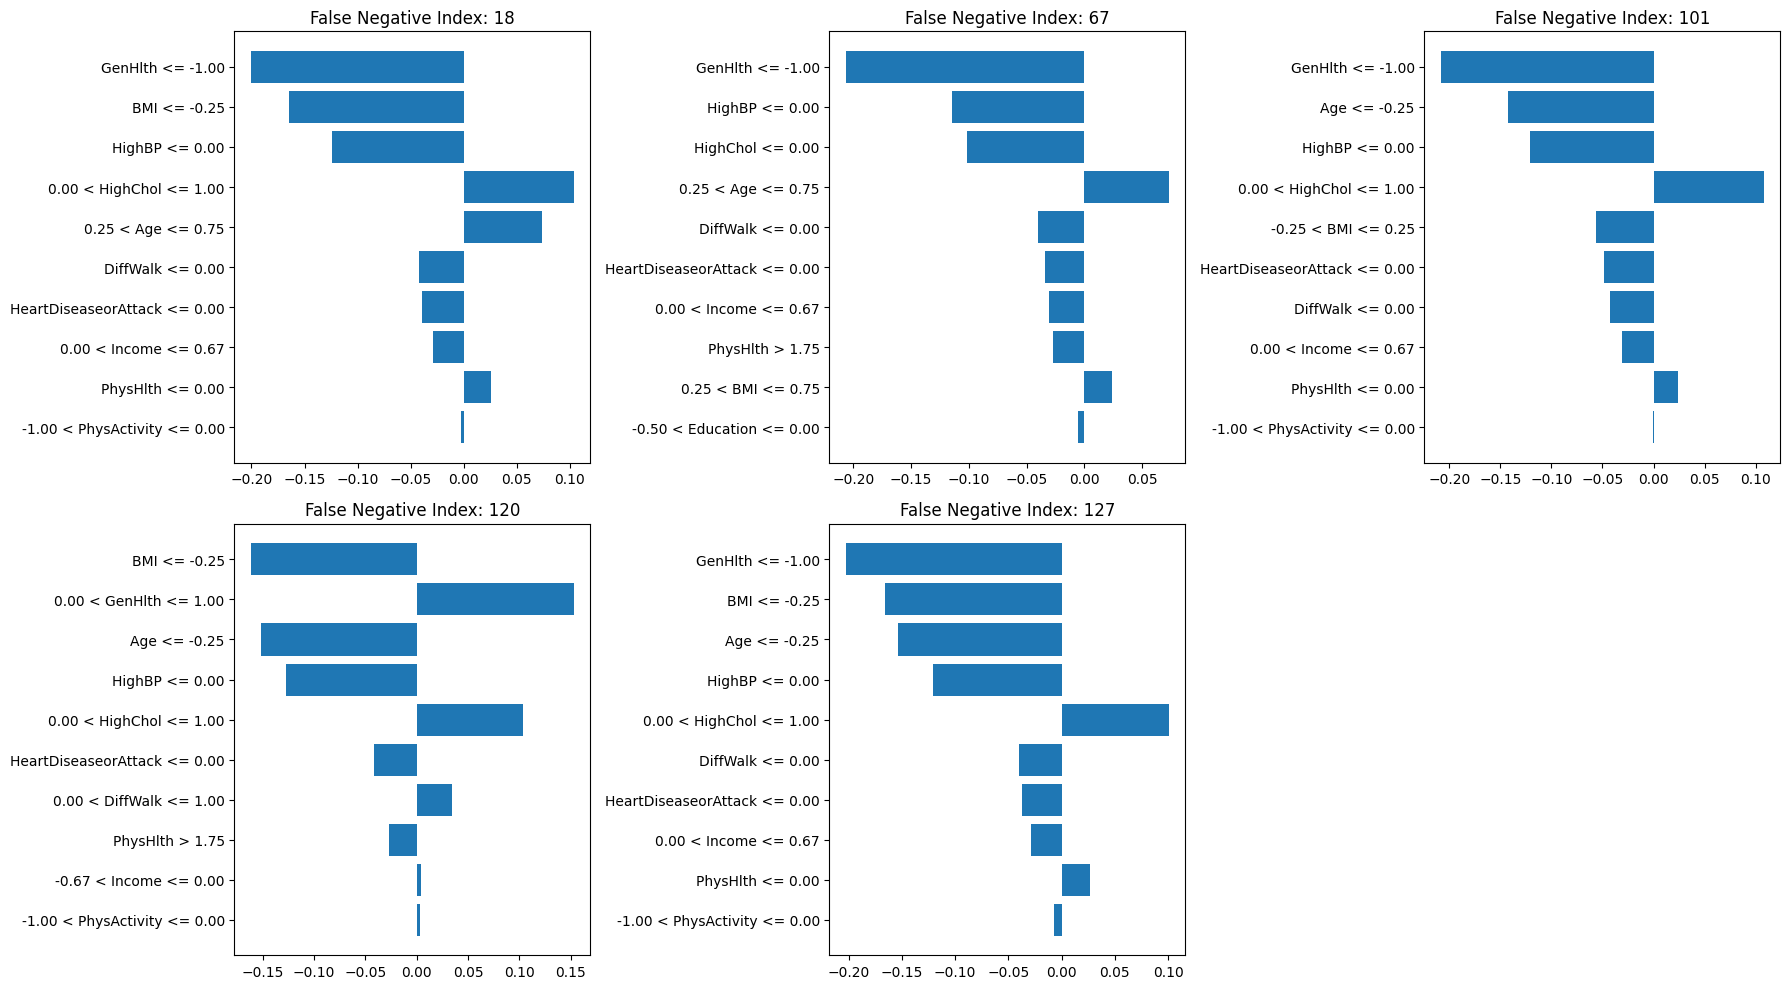

In [31]:
# Lime for a sample of false negatives
# Identify false negatives
false_negatives = np.where((y_test_np == 1) & (y_pred_prob_np < optimal_threshold))[0]

fn_explanations = []
# Explain a few false negatives
for i in false_negatives[:5]:  # Explain first 5 false negatives
    exp = explainer.explain_instance(
        data_row=X_test_np[i],
        predict_fn=lime_predict_fn,
        num_features=10
    )
    
    fn_explanations.append(exp)

# Plot LIME explanations for the false negatives in a 3-column grid
n_explanations = len(fn_explanations)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, exp in enumerate(fn_explanations):
    ax = axes[idx]
    
    # Get explanation as list of (feature, weight)
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"False Negative Index: {false_negatives[idx]}")

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

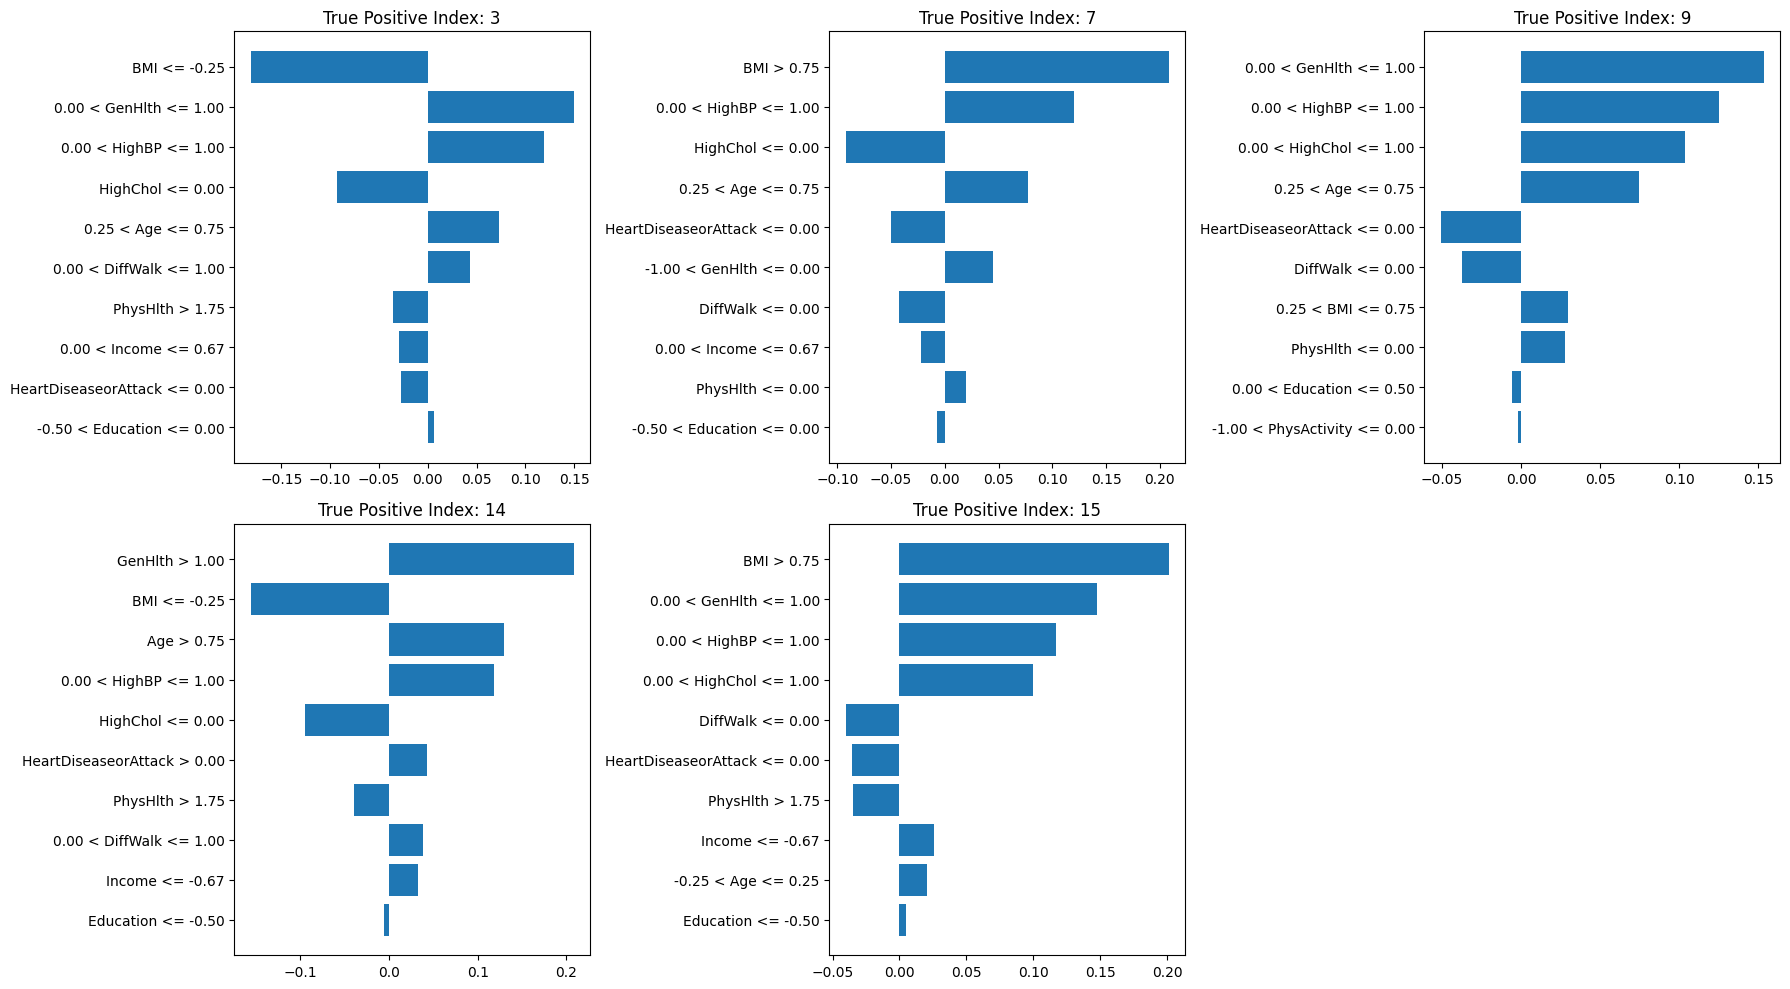

In [32]:
# Lime for a sample of true positives
# Identify true positives
true_positives = np.where((y_test_np == 1) & (y_pred_prob_np > optimal_threshold))[0]

tp_explanations = []
# Explain a few true positives
for i in true_positives[:5]:  # Explain first 5 true positives
    exp = explainer.explain_instance(
        data_row=X_test_np[i],
        predict_fn=lime_predict_fn,
        num_features=10
    )
    
    tp_explanations.append(exp)

# Plot LIME explanations for the true positives in a 3-column grid
n_explanations = len(tp_explanations)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, exp in enumerate(tp_explanations):
    ax = axes[idx]
    
    # Get explanation as list of (feature, weight)
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"True Positive Index: {true_positives[idx]}")

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()

### Export Model

In [33]:
# Export the model and shap values
torch.save(simple_model.state_dict(), '..\\models\\simple_model.pt')
joblib.dump(shap_values, '..\\models\\simple_shap_values.joblib')

['..\\models\\simple_shap_values.joblib']

## Enriched MLP

### Build the Model

In [53]:
# Define model
class Enriched(nn.Module):
    def __init__(self, input_size=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers_stack = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers_stack(x)
        return logits
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            x = self.flatten(x)
            logits = self.layers_stack(x)
            return logits


In [54]:
enriched_model = Enriched(input_size=len(top_features)).to(device)
print(enriched_model)

Enriched(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers_stack): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [55]:
optimizer_en = torch.optim.SGD(enriched_model.parameters(), lr=1e-3)

### Model Training

In [ ]:
loss_history = []
test_loss_history = []
test_accuracy_history = []
train_accuracy_history = []

tracker = EmissionsTracker()
tracker.start()

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    epoch_loss, epoch_accuracy = train(train_loader, enriched_model, loss_fn, optimizer_en)
    loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)

    test_loss, test_accuracy = test(test_loader, enriched_model, loss_fn)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)
    
enriched_emissions = tracker.stop()
print(f"Carbon footprint of training the model: {enriched_emissions} kg CO2")


[codecarbon WARNING @ 15:47:45] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:47:47] [setup] RAM Tracking...
[codecarbon INFO @ 15:47:47] [setup] CPU Tracking...
[codecarbon WARNING @ 15:47:47] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 15:47:47] CPU Model on constant consumption mode: AMD Ryzen 5 5625U with Radeon Graphics
[codecarbon WARNING @ 15:47:47] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 15:47:47] [setup] GPU Tracking...
[codecarbon INFO @ 15:47:47] No GPU found.
[codecarbon INFO @ 15:47:47] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 15:47:47] >>> Tracker's metadata:
[codecarbon INFO

Epoch 1
-------------------------------
loss: 0.688321  [   32/28077]
loss: 0.692013  [ 3232/28077]
loss: 0.696944  [ 6432/28077]
loss: 0.681680  [ 9632/28077]
loss: 0.686575  [12832/28077]
loss: 0.686227  [16032/28077]
loss: 0.688373  [19232/28077]
loss: 0.695329  [22432/28077]
loss: 0.690705  [25632/28077]
Test Error: 
 Accuracy: 50.4%, Avg loss: 0.691112 

Epoch 2
-------------------------------
loss: 0.692823  [   32/28077]
loss: 0.701117  [ 3232/28077]
loss: 0.697858  [ 6432/28077]
loss: 0.687811  [ 9632/28077]
loss: 0.682716  [12832/28077]
loss: 0.688804  [16032/28077]
loss: 0.685715  [19232/28077]
loss: 0.679590  [22432/28077]
loss: 0.685982  [25632/28077]
Test Error: 
 Accuracy: 59.3%, Avg loss: 0.686730 

Epoch 3
-------------------------------
loss: 0.691252  [   32/28077]
loss: 0.696952  [ 3232/28077]
loss: 0.693462  [ 6432/28077]
loss: 0.689301  [ 9632/28077]
loss: 0.681800  [12832/28077]
loss: 0.691598  [16032/28077]
loss: 0.688168  [19232/28077]
loss: 0.670104  [22432/280

[codecarbon INFO @ 15:48:07] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W


Test Error: 
 Accuracy: 69.2%, Avg loss: 0.674228 

Epoch 5
-------------------------------
loss: 0.681897  [   32/28077]


[codecarbon INFO @ 15:48:08] Delta energy consumed for CPU with cpu_load : 0.000037 kWh, power : 8.2464115785 W
[codecarbon INFO @ 15:48:08] Energy consumed for All CPU : 0.000037 kWh
[codecarbon INFO @ 15:48:08] 0.000081 kWh of electricity and 0.000000 L of water were used since the beginning.


...

Test Error: 
 Accuracy: 72.9%, Avg loss: 0.539099 

Epoch 49
-------------------------------
loss: 0.472124  [   32/28077]
loss: 0.632583  [ 3232/28077]
loss: 0.489034  [ 6432/28077]
loss: 0.697820  [ 9632/28077]
loss: 0.595982  [12832/28077]
loss: 0.562411  [16032/28077]
loss: 0.515079  [19232/28077]
loss: 0.514388  [22432/28077]
loss: 0.393546  [25632/28077]
Test Error: 
 Accuracy: 72.9%, Avg loss: 0.538990 

Epoch 50
-------------------------------
loss: 0.470471  [   32/28077]
loss: 0.606216  [ 3232/28077]
loss: 0.691694  [ 6432/28077]
loss: 0.442733  [ 9632/28077]
loss: 0.579663  [12832/28077]
loss: 0.645001  [16032/28077]
loss: 0.547459  [19232/28077]
loss: 0.518269  [22432/28077]
loss: 0.578964  [25632/28077]


[codecarbon INFO @ 15:51:21] Energy consumed for RAM : 0.000564 kWh. RAM Power : 10.0 W


Test Error: 
 Accuracy: 72.9%, Avg loss: 0.538889 



[codecarbon INFO @ 15:51:21] Delta energy consumed for CPU with cpu_load : 0.000045 kWh, power : 12.3351089991 W
[codecarbon INFO @ 15:51:21] Energy consumed for All CPU : 0.000524 kWh
[codecarbon INFO @ 15:51:21] 0.001088 kWh of electricity and 0.000000 L of water were used since the beginning.


Carbon footprint of training the model: 6.0993405652376724e-05 kg CO2


### Model Evaluation

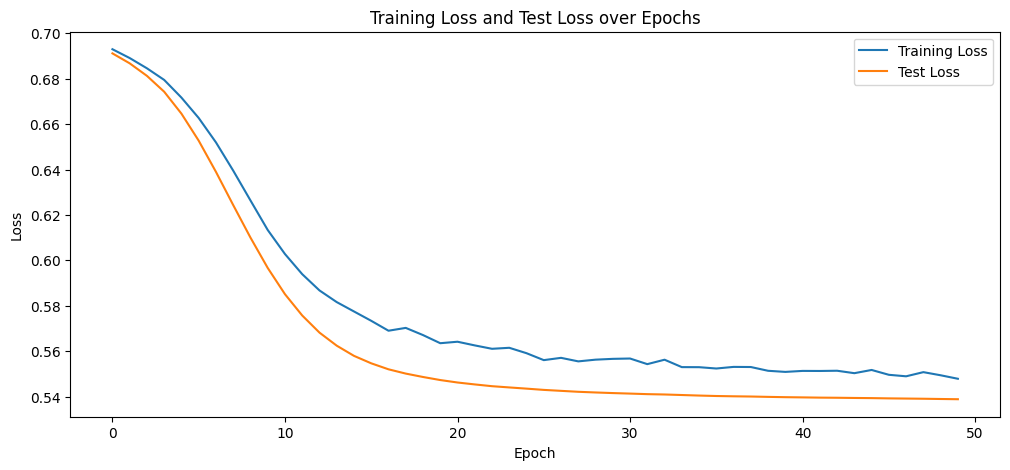

In [57]:
# Plotting the training loss and test loss history on the same graph
plt.figure(figsize=(12, 5))
plt.plot(loss_history, label='Training Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss and Test Loss over Epochs')
plt.legend()
plt.show()


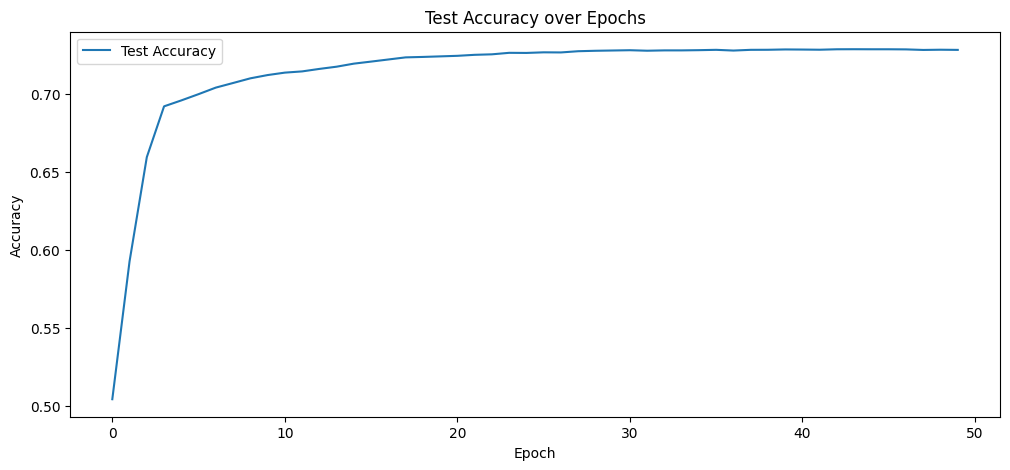

In [58]:
# plotting the test accuracy history
plt.figure(figsize=(12, 5))
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs')
plt.legend()
plt.show()


In [59]:
# Classification report and confusion matrix
enriched_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = enriched_model.predict(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > 0.5).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

         0.0       0.77      0.66      0.71     14039
         1.0       0.70      0.80      0.75     14039

    accuracy                           0.73     28078
   macro avg       0.73      0.73      0.73     28078
weighted avg       0.73      0.73      0.73     28078



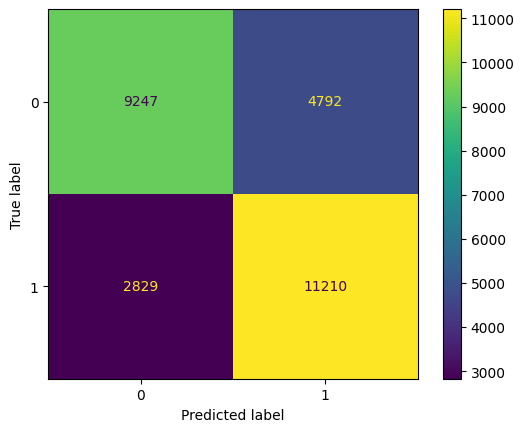

In [60]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Threshold Analysis

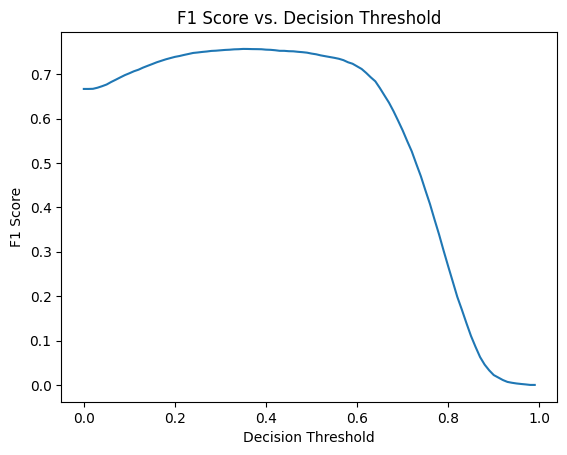

In [61]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [62]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold_enriched = thresholds[max_f1_index]
print(f"Optimal Threshold: {optimal_threshold_enriched:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}")

Optimal Threshold: 0.35 with F1 Score: 0.7568


In [63]:
# Classification report and confusion matrix
enriched_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = enriched_model.predict(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > optimal_threshold_enriched).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.54      0.66     14039
         1.0       0.66      0.89      0.76     14039

    accuracy                           0.71     28078
   macro avg       0.74      0.71      0.71     28078
weighted avg       0.74      0.71      0.71     28078



### ExAI

#### SHAP

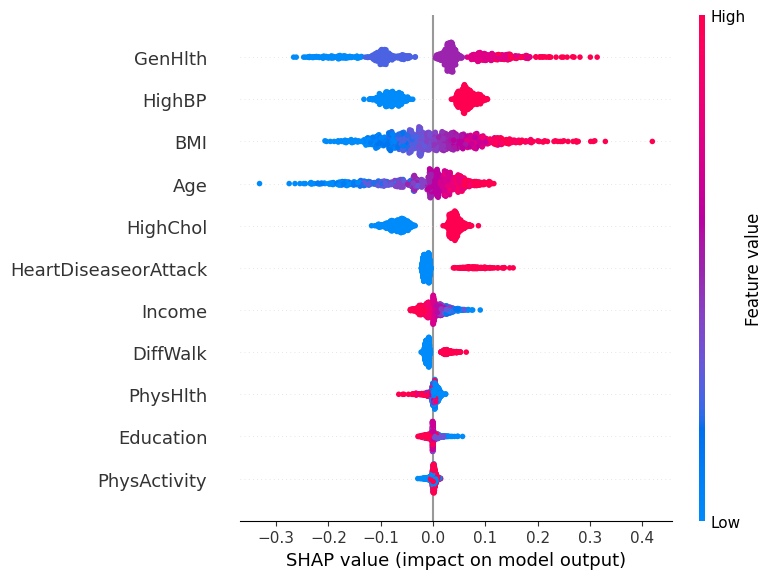

In [64]:
# Ensure background dataset matches the training data
background = X_train.sample(100).to_numpy()
background = torch.tensor(background, dtype=torch.float32).to(device)

# Ensure test samples match the model input
test_samples = torch.tensor(X_test.iloc[:1000].to_numpy(), dtype=torch.float32).to(device)
test_samples_np = test_samples.cpu().numpy()

# Initialize SHAP explainer
e_enriched = shap.DeepExplainer(enriched_model, background)

# Compute SHAP values
shap_values_enriched = e_enriched.shap_values(test_samples)

# --- FIX: Normalize shap_values to a 2D array ---
if isinstance(shap_values_enriched, list):
    # Multi-output model: pick class index 1 (positive class) or 0
    shap_vals_to_plot = shap_values_enriched[1] if len(shap_values_enriched) > 1 else shap_values_enriched[0]
else:
    # Single array — may be 3D: (samples, features, outputs)
    if shap_values_enriched.ndim == 3:
        shap_vals_to_plot = shap_values_enriched[:, :, 1] if shap_values_enriched.shape[2] > 1 else shap_values_enriched[:, :, 0]
    else:
        shap_vals_to_plot = shap_values_enriched  # Already 2D, use directly

# Verify shapes match before plotting
assert shap_vals_to_plot.shape == test_samples_np.shape, (
    f"Shape mismatch: shap={shap_vals_to_plot.shape}, data={test_samples_np.shape}"
)

# Plot SHAP summary
shap.summary_plot(shap_vals_to_plot, test_samples_np, feature_names=top_features)

#### Lime

In [65]:
# Prepare data for LIME
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convert y_pred_prob to numpy array if it's a list of arrays
if isinstance(y_pred_prob, list):
    y_pred_prob_np = np.array([float(x) if np.isscalar(x) else float(x[0]) for x in y_pred_prob])
else:
    y_pred_prob_np = y_pred_prob
    
# LIME expects a function that takes a numpy array and returns probabilities
def lime_predict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = enriched_model(x_tensor).cpu().numpy()
    # LIME expects a 2D array with probabilities for both classes
    preds = np.concatenate([1 - preds, preds], axis=1)
    return preds

# Initialize LIME explainer
enriched_explainer = lime_tabular.LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=top_features,
    class_names=['No Diabetes', 'Diabetes'],
    discretize_continuous=True
)

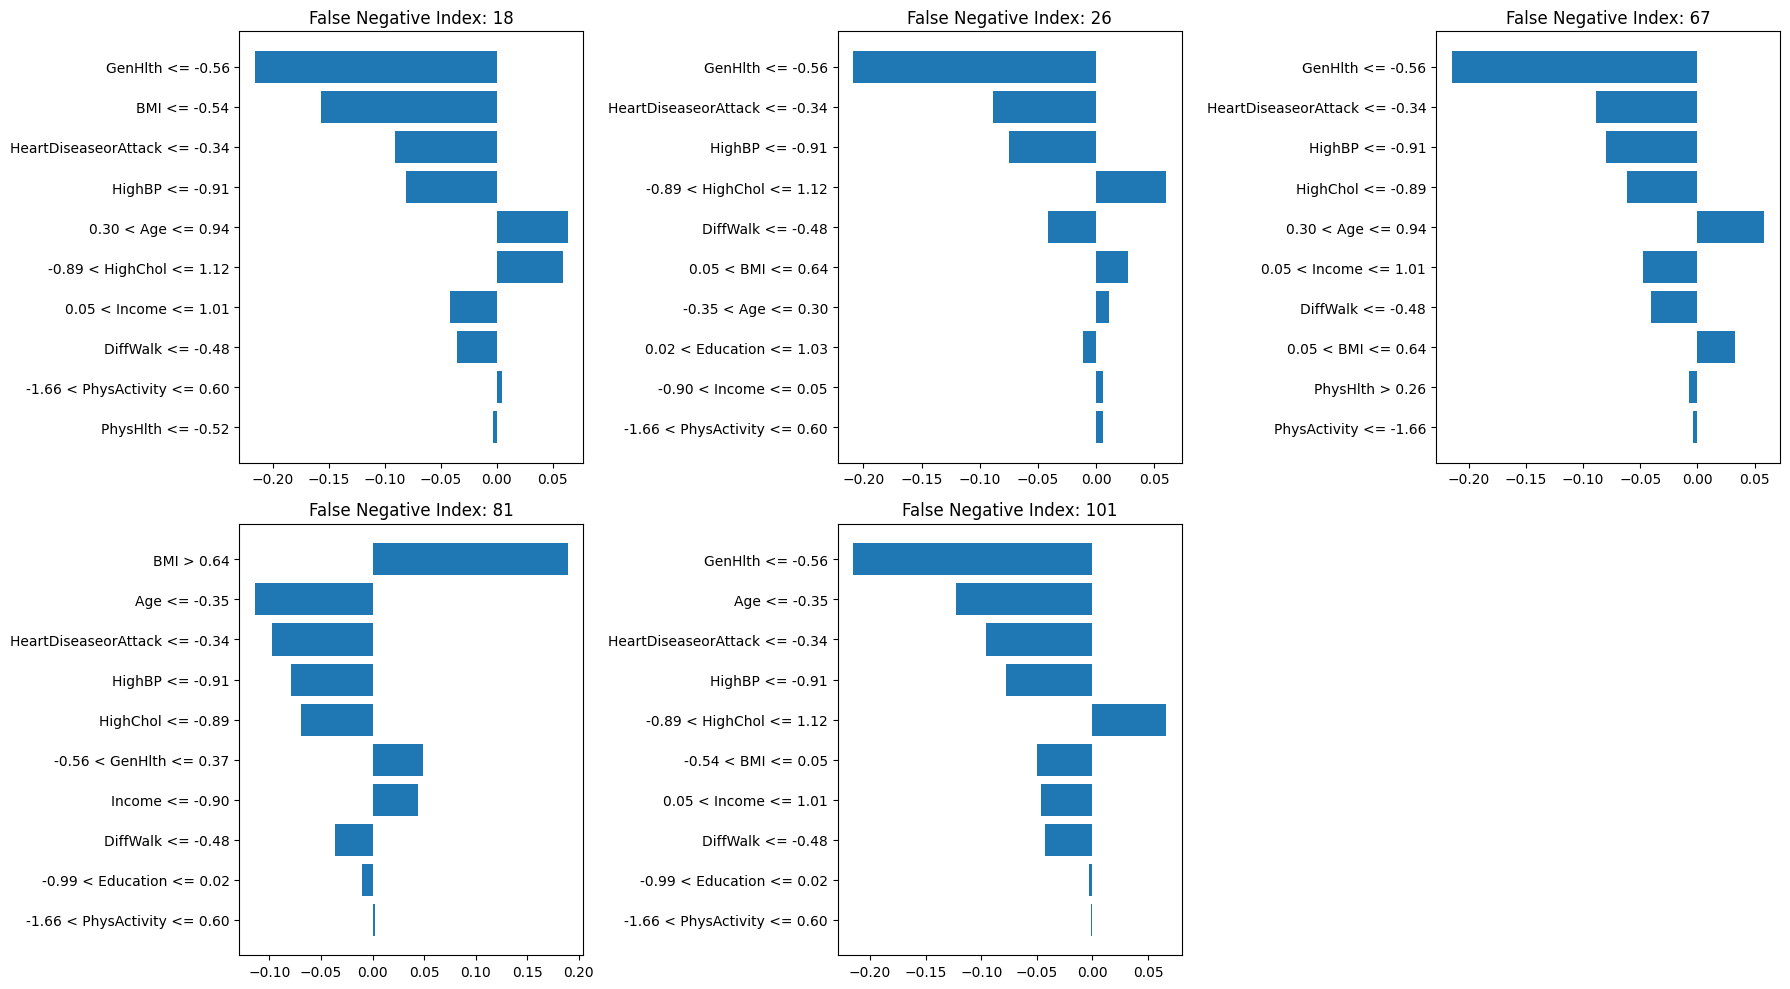

In [66]:
# Lime for a sample of false negatives
# Identify false negatives
false_negatives = np.where((y_test_np == 1) & (y_pred_prob_np < optimal_threshold_enriched))[0]

fn_explanations = []
# Explain a few false negatives
for i in false_negatives[:5]:  # Explain first 5 false negatives
    exp = enriched_explainer.explain_instance(
        data_row=X_test_np[i],
        predict_fn=lime_predict_fn,
        num_features=10
    )
    
    fn_explanations.append(exp)

# Plot LIME explanations for the false negatives in a 3-column grid
n_explanations = len(fn_explanations)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, exp in enumerate(fn_explanations):
    ax = axes[idx]
    
    # Get explanation as list of (feature, weight)
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"False Negative Index: {false_negatives[idx]}")

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

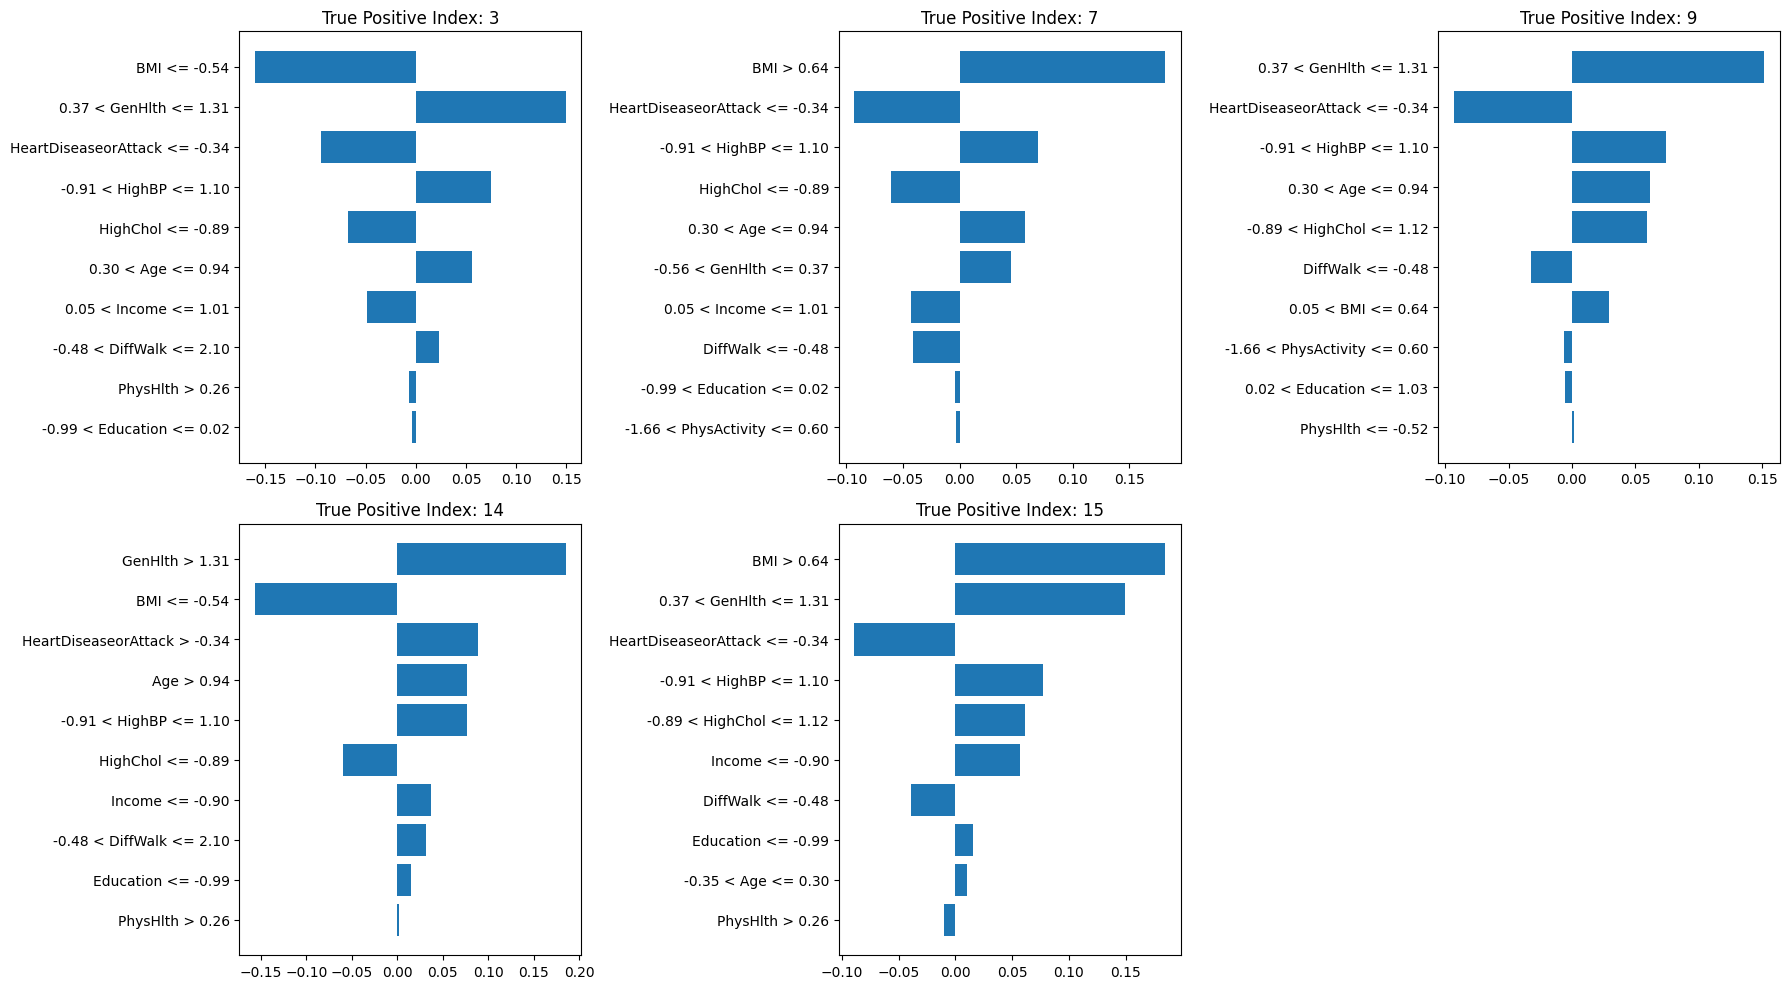

In [67]:
# Lime for a sample of true positives
# Identify true positives
true_positives = np.where((y_test_np == 1) & (y_pred_prob_np > optimal_threshold_enriched))[0]

tp_explanations = []
# Explain a few true positives
for i in true_positives[:5]:  # Explain first 5 true positives
    exp = enriched_explainer.explain_instance(
        data_row=X_test_np[i],
        predict_fn=lime_predict_fn,
        num_features=10
    )
    
    tp_explanations.append(exp)

# Plot LIME explanations for the true positives in a 3-column grid
n_explanations = len(tp_explanations)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, exp in enumerate(tp_explanations):
    ax = axes[idx]
    
    # Get explanation as list of (feature, weight)
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"True Positive Index: {true_positives[idx]}")

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()

### Export Model

In [68]:
# Export the model and shap values
torch.save(enriched_model.layers_stack.state_dict(), '..\\models\\enriched_model.pt')
joblib.dump(shap_values_enriched, '..\\models\\enriched_shap_values.joblib')

['..\\models\\enriched_shap_values.joblib']

## XGB Model

In [50]:
# Create an XGBoost model for comparison
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
)

In [51]:
xgb_tracker = EmissionsTracker()
xgb_tracker.start()
xgb_model.fit(X_train, y_train)
xgb_emissions = xgb_tracker.stop()
print(f"Carbon footprint of training the XGBoost model: {xgb_emissions} kg CO2")

[codecarbon WARNING @ 12:31:02] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 12:31:04] [setup] RAM Tracking...
[codecarbon INFO @ 12:31:04] [setup] CPU Tracking...
[codecarbon WARNING @ 12:31:04] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 12:31:04] CPU Model on constant consumption mode: AMD Ryzen 5 5625U with Radeon Graphics
[codecarbon WARNING @ 12:31:04] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 12:31:04] [setup] GPU Tracking...
[codecarbon INFO @ 12:31:04] No GPU found.
[codecarbon INFO @ 12:31:04] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 12:31:04] >>> Tracker's metadata:
[codecarbon INFO

Carbon footprint of training the XGBoost model: 2.6149350356976375e-07 kg CO2


### Model Evaluation

In [52]:
xgbpred = xgb_model.predict(X_test)
print(classification_report(y_test, xgbpred))

              precision    recall  f1-score   support

           0       0.75      0.69      0.72     14039
           1       0.71      0.77      0.74     14039

    accuracy                           0.73     28078
   macro avg       0.73      0.73      0.73     28078
weighted avg       0.73      0.73      0.73     28078



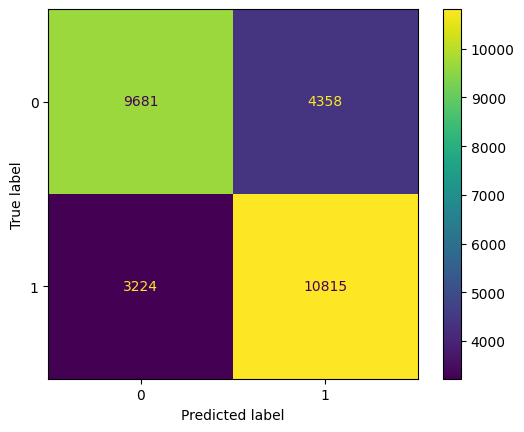

In [53]:
# confusion matrix for xgboost
cm = confusion_matrix(y_test, xgbpred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Hyperparameter Tuning

### ExAI

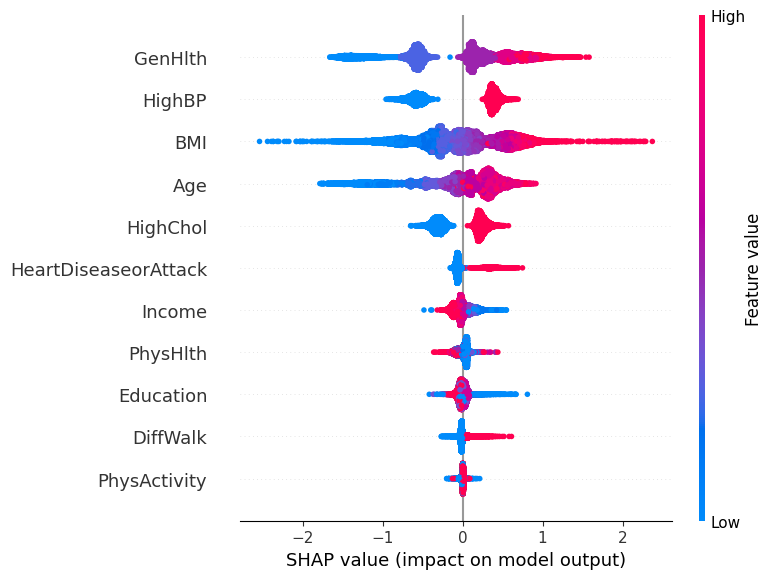

In [54]:
# SHAP values for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)
shap.summary_plot(shap_values_xgb, X_test, feature_names=top_features)

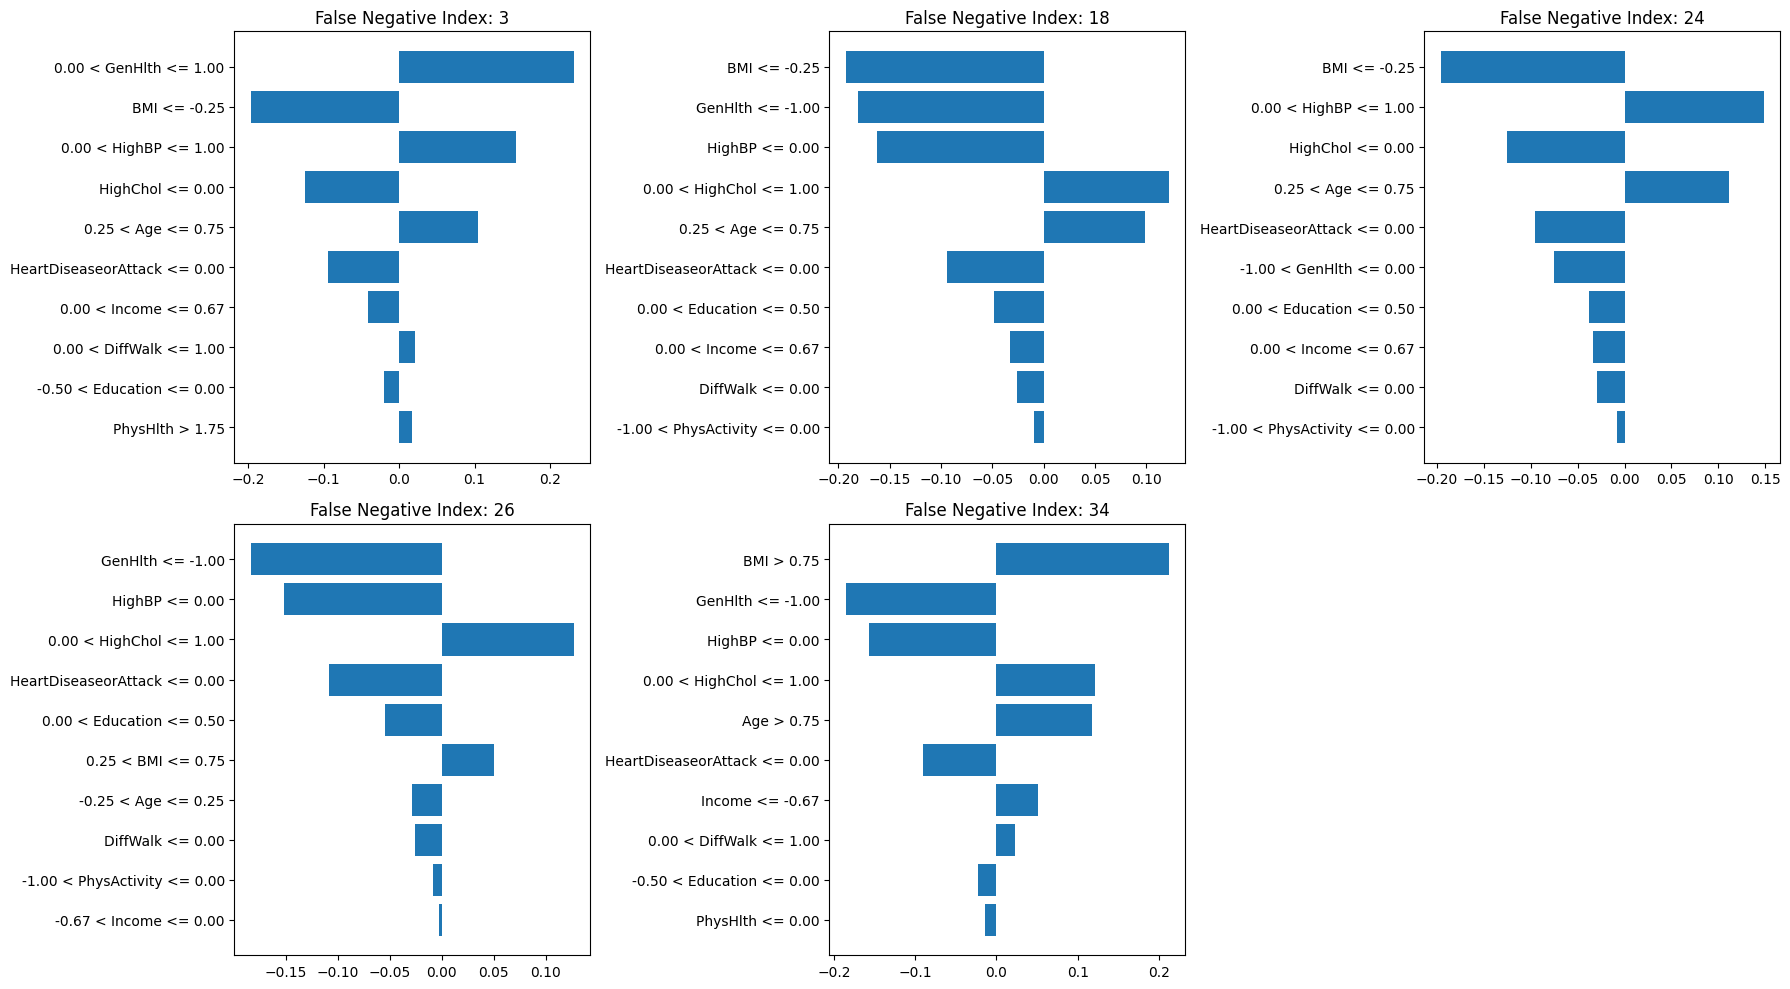

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=top_features,
    class_names=['No Diabetes', 'Diabetes'],
    discretize_continuous=True
)

def lime_predict_fn_xgb(x):
    preds = xgb_model.predict_proba(x)[:, 1]  # (n,)
    return np.vstack((1 - preds, preds)).T    # (n, 2)

# Ensure numpy arrays for indexing
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test
xgbpred_np = xgbpred if isinstance(xgbpred, np.ndarray) else np.array(xgbpred)

false_negatives_xgb = np.where((y_test_np == 1) & (xgbpred_np == 0))[0]

fn_explanations_xgb = []
for i in false_negatives_xgb[:5]:
    exp = explainer.explain_instance(
        data_row=X_test.iloc[i].to_numpy(),
        predict_fn=lime_predict_fn_xgb,
        num_features=10
    )
    fn_explanations_xgb.append(exp)

# Plot
n_explanations = len(fn_explanations_xgb)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Ensure axes is always iterable
axes = np.array(axes).reshape(-1)

for idx, exp in enumerate(fn_explanations_xgb):
    ax = axes[idx]
    
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"False Negative Index: {false_negatives_xgb[idx]}")

# Remove unused axes
for j in range(len(fn_explanations_xgb), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Post Hyperparameter Tuning MLP

### Build the Model

In [17]:
# Define model
class Enriched(nn.Module):
    def __init__(self, input_size=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers_stack = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4408140004471409),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4408140004471409),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Dropout(0.4408140004471409),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers_stack(x)
        return logits
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            x = self.flatten(x)
            logits = self.layers_stack(x)
            return logits


In [18]:
enriched_model = Enriched(input_size=len(top_features)).to(device)
print(enriched_model)

Enriched(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers_stack): Sequential(
    (0): Linear(in_features=11, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4408140004471409, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4408140004471409, inplace=False)
    (6): Linear(in_features=64, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.4408140004471409, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [21]:
optimizer_en = torch.optim.Adam(enriched_model.parameters(), lr=1.9287965519066394e-05)

### Model Training

In [22]:
loss_history = []
test_loss_history = []
test_accuracy_history = []
train_accuracy_history = []

tracker = EmissionsTracker()
tracker.start()

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    epoch_loss, epoch_accuracy = train(train_loader, enriched_model, loss_fn, optimizer_en)
    loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)

    test_loss, test_accuracy = test(test_loader, enriched_model, loss_fn)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)
    
enriched_emissions = tracker.stop()
print(f"Carbon footprint of training the model: {enriched_emissions} kg CO2")


[codecarbon WARNING @ 07:44:39] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 07:44:43] [setup] RAM Tracking...
[codecarbon INFO @ 07:44:43] [setup] CPU Tracking...
[codecarbon WARNING @ 07:44:43] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 07:44:43] CPU Model on constant consumption mode: AMD Ryzen 5 5625U with Radeon Graphics
[codecarbon WARNING @ 07:44:43] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 07:44:43] [setup] GPU Tracking...
[codecarbon INFO @ 07:44:43] No GPU found.
[codecarbon INFO @ 07:44:43] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 07:44:43] >>> Tracker's metadata:
[codecarbon INFO

Epoch 1
-------------------------------
loss: 0.677189  [   32/28077]
loss: 0.695822  [ 3232/28077]
loss: 0.677820  [ 6432/28077]
loss: 0.688255  [ 9632/28077]
loss: 0.682926  [12832/28077]
loss: 0.676358  [16032/28077]
loss: 0.679303  [19232/28077]
loss: 0.678200  [22432/28077]
loss: 0.670371  [25632/28077]
Test Error: 
 Accuracy: 70.3%, Avg loss: 0.657207 

Epoch 2
-------------------------------
loss: 0.664078  [   32/28077]
loss: 0.644499  [ 3232/28077]
loss: 0.651987  [ 6432/28077]
loss: 0.658240  [ 9632/28077]
loss: 0.652034  [12832/28077]
loss: 0.633012  [16032/28077]
loss: 0.654116  [19232/28077]
loss: 0.658279  [22432/28077]
loss: 0.662208  [25632/28077]


[codecarbon INFO @ 07:45:00] Energy consumed for RAM : 0.000286 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:45:01] Delta energy consumed for CPU with cpu_load : 0.000030 kWh, power : 7.362383177625 W
[codecarbon INFO @ 07:45:01] Energy consumed for All CPU : 0.000164 kWh
[codecarbon INFO @ 07:45:01] 0.000450 kWh of electricity and 0.000000 L of water were used since the beginning.


Test Error: 
 Accuracy: 71.8%, Avg loss: 0.615602 

Epoch 3
-------------------------------
loss: 0.675011  [   32/28077]
loss: 0.622484  [ 3232/28077]
loss: 0.556606  [ 6432/28077]
loss: 0.590002  [ 9632/28077]
loss: 0.573628  [12832/28077]
loss: 0.559553  [16032/28077]


[codecarbon INFO @ 07:45:04] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W


...

loss: 0.580851  [ 6432/28077]
loss: 0.681166  [ 9632/28077]
loss: 0.592053  [12832/28077]
loss: 0.428593  [16032/28077]
loss: 0.597307  [19232/28077]
loss: 0.711202  [22432/28077]
loss: 0.559552  [25632/28077]
Test Error: 
 Accuracy: 73.1%, Avg loss: 0.534474 

Epoch 50
-------------------------------
loss: 0.774160  [   32/28077]
loss: 0.596315  [ 3232/28077]
loss: 0.566726  [ 6432/28077]
loss: 0.537940  [ 9632/28077]
loss: 0.697173  [12832/28077]
loss: 0.487527  [16032/28077]
loss: 0.499757  [19232/28077]
loss: 0.630946  [22432/28077]
loss: 0.612806  [25632/28077]


[codecarbon INFO @ 07:49:45] Energy consumed for RAM : 0.000798 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:49:45] Energy consumed for RAM : 0.001051 kWh. RAM Power : 10.0 W


Test Error: 
 Accuracy: 73.1%, Avg loss: 0.534512 



[codecarbon INFO @ 07:49:46] Delta energy consumed for CPU with cpu_load : 0.000019 kWh, power : 6.39809186877273 W
[codecarbon INFO @ 07:49:46] Energy consumed for All CPU : 0.000718 kWh
[codecarbon INFO @ 07:49:46] 0.001516 kWh of electricity and 0.000000 L of water were used since the beginning.


Carbon footprint of training the model: 8.497666811260629e-05 kg CO2


### Model Evaluation

[codecarbon INFO @ 07:49:46] Delta energy consumed for CPU with cpu_load : 0.000026 kWh, power : 6.549046686375001 W
[codecarbon INFO @ 07:49:46] Energy consumed for All CPU : 0.000851 kWh
[codecarbon INFO @ 07:49:46] 0.001902 kWh of electricity and 0.000000 L of water were used since the beginning.


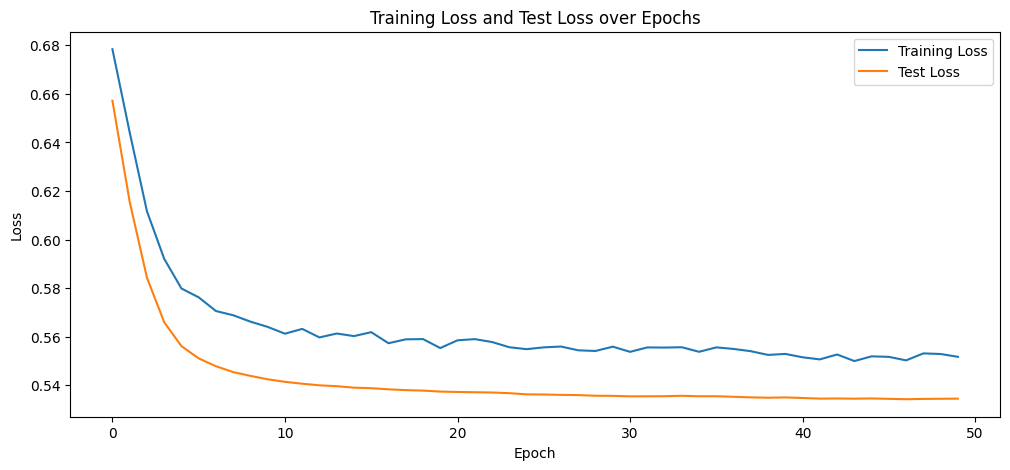

In [23]:
# Plotting the training loss and test loss history on the same graph
plt.figure(figsize=(12, 5))
plt.plot(loss_history, label='Training Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss and Test Loss over Epochs')
plt.legend()
plt.show()


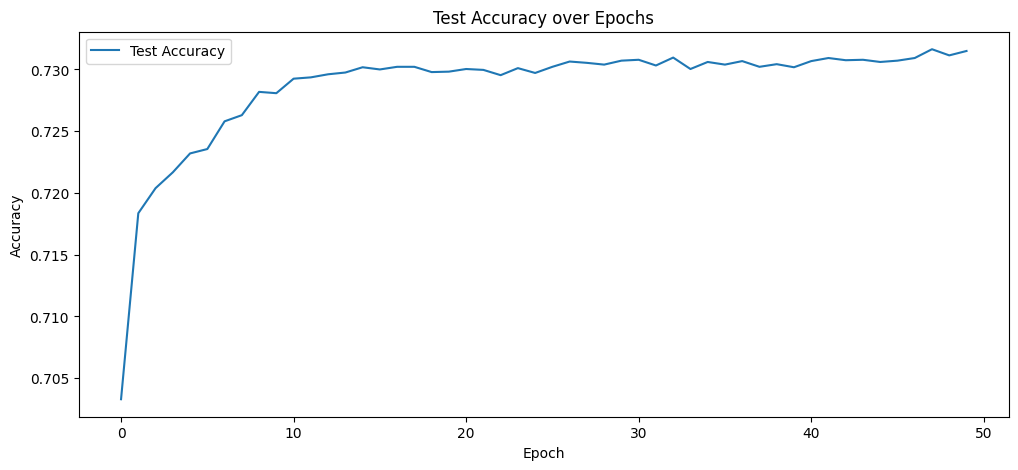

In [24]:
# plotting the test accuracy history
plt.figure(figsize=(12, 5))
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs')
plt.legend()
plt.show()


In [25]:
# Classification report and confusion matrix
enriched_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = enriched_model.predict(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > 0.5).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

         0.0       0.75      0.69      0.72     14039
         1.0       0.71      0.77      0.74     14039

    accuracy                           0.73     28078
   macro avg       0.73      0.73      0.73     28078
weighted avg       0.73      0.73      0.73     28078



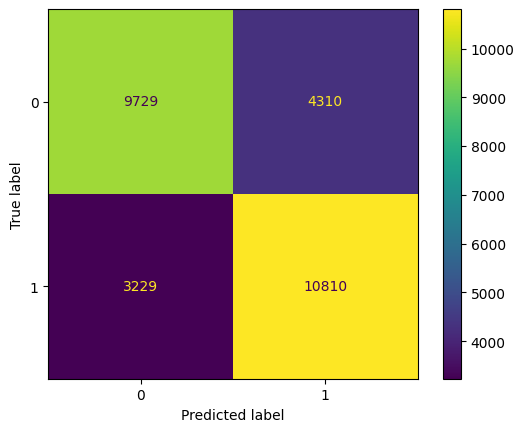

In [26]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Threshold Analysis

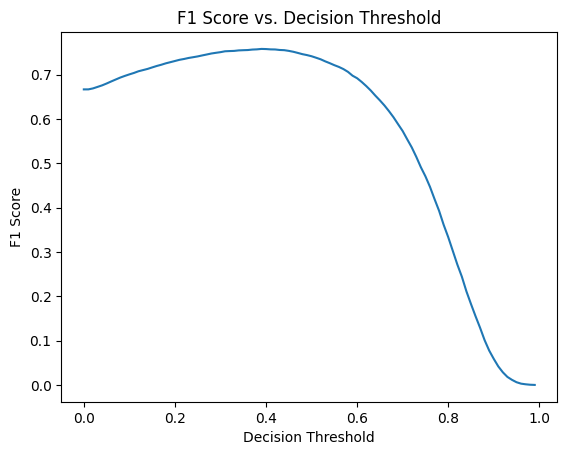

In [27]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [28]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold_enriched = thresholds[max_f1_index]
print(f"Optimal Threshold: {optimal_threshold_enriched:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}")

Optimal Threshold: 0.39 with F1 Score: 0.7580


In [29]:
# Classification report and confusion matrix
enriched_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = enriched_model.predict(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > optimal_threshold_enriched).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.55      0.66     14039
         1.0       0.66      0.89      0.76     14039

    accuracy                           0.72     28078
   macro avg       0.75      0.72      0.71     28078
weighted avg       0.75      0.72      0.71     28078



### ExAI

#### SHAP

[codecarbon INFO @ 07:50:00] Energy consumed for RAM : 0.001091 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:50:01] Delta energy consumed for CPU with cpu_load : 0.000023 kWh, power : 5.7444510516 W
[codecarbon INFO @ 07:50:01] Energy consumed for All CPU : 0.000874 kWh
[codecarbon INFO @ 07:50:01] 0.001965 kWh of electricity and 0.000000 L of water were used since the beginning.


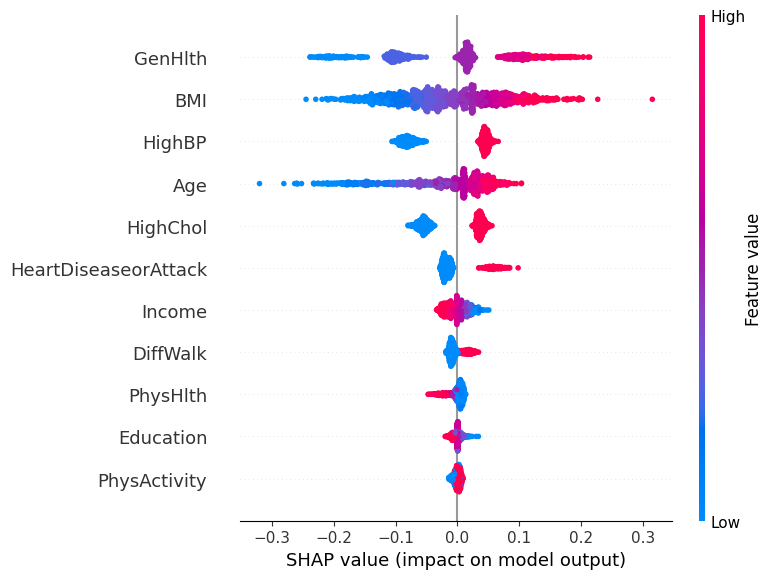

In [30]:
# Ensure background dataset matches the training data
background = X_train.sample(100).to_numpy()
background = torch.tensor(background, dtype=torch.float32).to(device)

# Ensure test samples match the model input
test_samples = torch.tensor(X_test.iloc[:1000].to_numpy(), dtype=torch.float32).to(device)
test_samples_np = test_samples.cpu().numpy()

# Initialize SHAP explainer
e_enriched = shap.DeepExplainer(enriched_model, background)

# Compute SHAP values
shap_values_enriched = e_enriched.shap_values(test_samples)

# --- FIX: Normalize shap_values to a 2D array ---
if isinstance(shap_values_enriched, list):
    # Multi-output model: pick class index 1 (positive class) or 0
    shap_vals_to_plot = shap_values_enriched[1] if len(shap_values_enriched) > 1 else shap_values_enriched[0]
else:
    # Single array — may be 3D: (samples, features, outputs)
    if shap_values_enriched.ndim == 3:
        shap_vals_to_plot = shap_values_enriched[:, :, 1] if shap_values_enriched.shape[2] > 1 else shap_values_enriched[:, :, 0]
    else:
        shap_vals_to_plot = shap_values_enriched  # Already 2D, use directly

# Verify shapes match before plotting
assert shap_vals_to_plot.shape == test_samples_np.shape, (
    f"Shape mismatch: shap={shap_vals_to_plot.shape}, data={test_samples_np.shape}"
)

# Plot SHAP summary
shap.summary_plot(shap_vals_to_plot, test_samples_np, feature_names=top_features)

#### Lime

In [31]:
# Prepare data for LIME
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convert y_pred_prob to numpy array if it's a list of arrays
if isinstance(y_pred_prob, list):
    y_pred_prob_np = np.array([float(x) if np.isscalar(x) else float(x[0]) for x in y_pred_prob])
else:
    y_pred_prob_np = y_pred_prob
    
# LIME expects a function that takes a numpy array and returns probabilities
def lime_predict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = enriched_model(x_tensor).cpu().numpy()
    # LIME expects a 2D array with probabilities for both classes
    preds = np.concatenate([1 - preds, preds], axis=1)
    return preds

# Initialize LIME explainer
enriched_explainer = lime_tabular.LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=top_features,
    class_names=['No Diabetes', 'Diabetes'],
    discretize_continuous=True
)

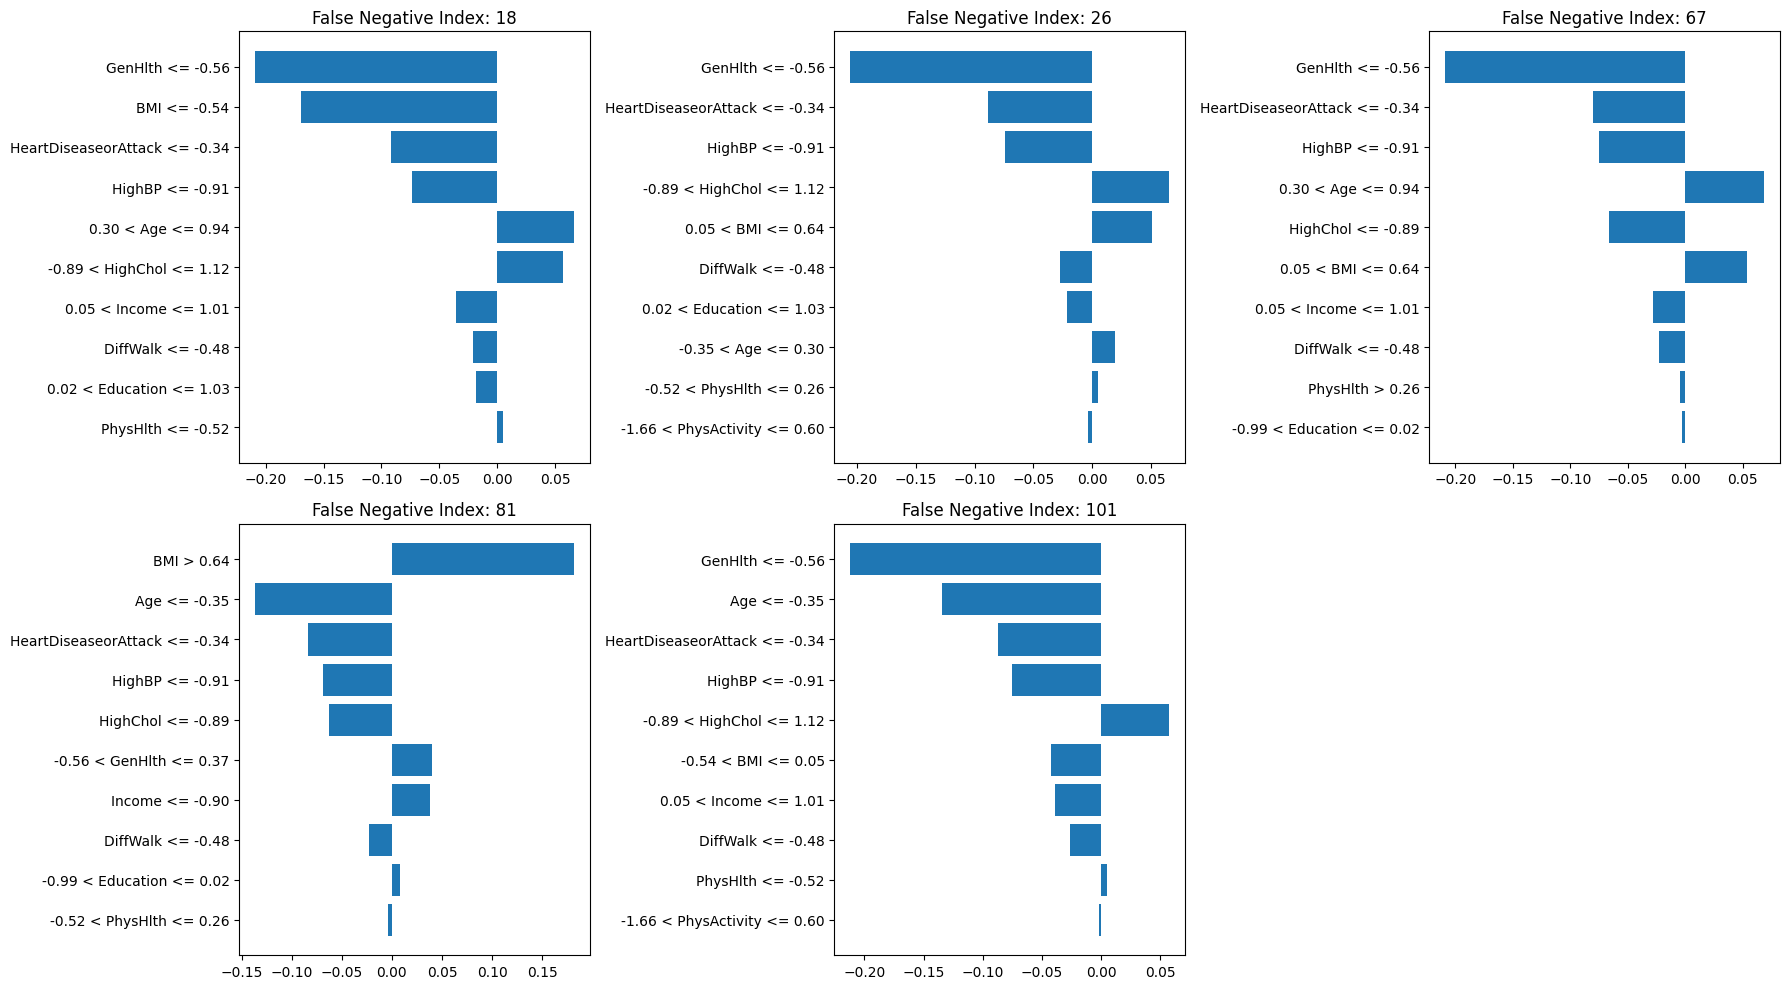

In [32]:
# Lime for a sample of false negatives
# Identify false negatives
false_negatives = np.where((y_test_np == 1) & (y_pred_prob_np < optimal_threshold_enriched))[0]

fn_explanations = []
# Explain a few false negatives
for i in false_negatives[:5]:  # Explain first 5 false negatives
    exp = enriched_explainer.explain_instance(
        data_row=X_test_np[i],
        predict_fn=lime_predict_fn,
        num_features=10
    )
    
    fn_explanations.append(exp)

# Plot LIME explanations for the false negatives in a 3-column grid
n_explanations = len(fn_explanations)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, exp in enumerate(fn_explanations):
    ax = axes[idx]
    
    # Get explanation as list of (feature, weight)
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"False Negative Index: {false_negatives[idx]}")

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

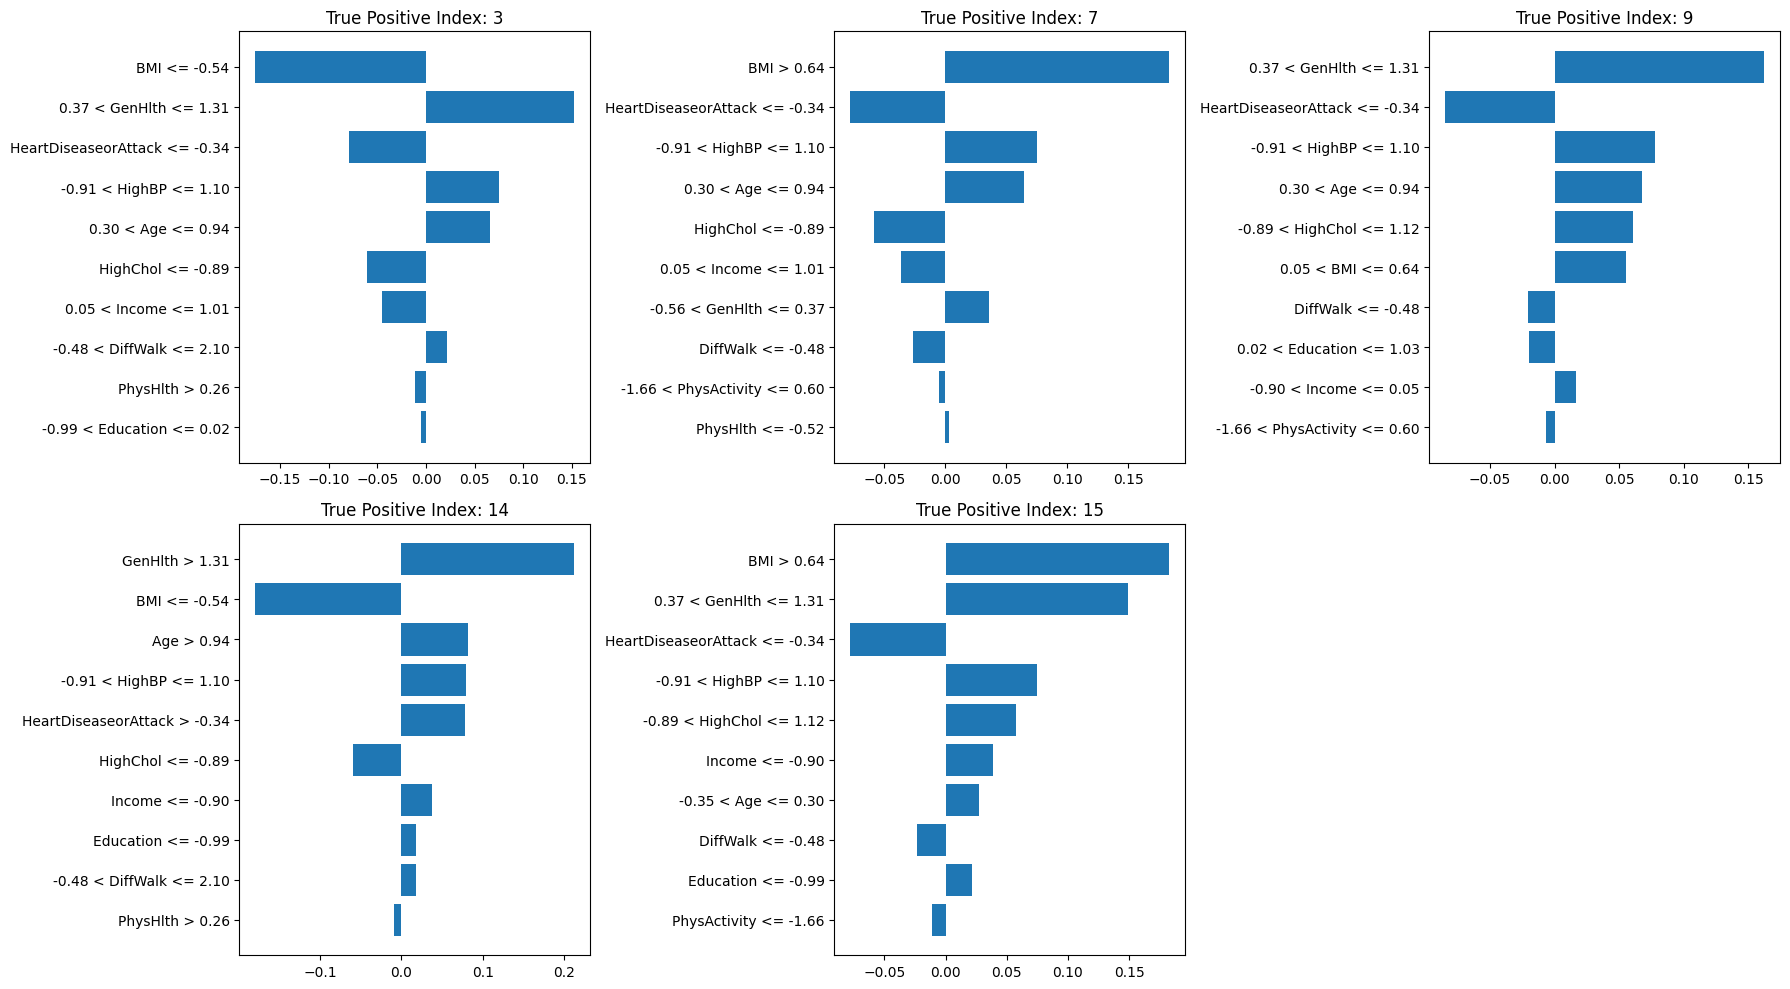

[codecarbon INFO @ 07:50:15] Energy consumed for RAM : 0.001131 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:50:16] Delta energy consumed for CPU with cpu_load : 0.000016 kWh, power : 4.026068931187501 W
[codecarbon INFO @ 07:50:16] Energy consumed for All CPU : 0.000890 kWh
[codecarbon INFO @ 07:50:16] 0.002022 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 07:50:30] Energy consumed for RAM : 0.001172 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:50:31] Delta energy consumed for CPU with cpu_load : 0.000007 kWh, power : 1.6622575605937502 W
[codecarbon INFO @ 07:50:31] Energy consumed for All CPU : 0.000897 kWh
[codecarbon INFO @ 07:50:31] 0.002069 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 07:50:45] Energy consumed for RAM : 0.001212 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:50:46] Delta energy consumed for CPU with cpu_load : 0.000006 kWh, power : 1.5726758983125002 W
[codecarbon INF

In [ ]:
# Lime for a sample of true positives
# Identify true positives
true_positives = np.where((y_test_np == 1) & (y_pred_prob_np > optimal_threshold_enriched))[0]

tp_explanations = []
# Explain a few true positives
for i in true_positives[:5]:  # Explain first 5 true positives
    exp = enriched_explainer.explain_instance(
        data_row=X_test_np[i],
        predict_fn=lime_predict_fn,
        num_features=10
    )
    
    tp_explanations.append(exp)

# Plot LIME explanations for the true positives in a 3-column grid
n_explanations = len(tp_explanations)
n_cols = 3
n_rows = int(np.ceil(n_explanations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, exp in enumerate(tp_explanations):
    ax = axes[idx]
    
    # Get explanation as list of (feature, weight)
    exp_list = exp.as_list()
    features, weights = zip(*exp_list)
    
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()
    
    ax.set_title(f"True Positive Index: {true_positives[idx]}")

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()

### Export Model

In [ ]:
# Export the model and shap values
torch.save(enriched_model.layers_stack.state_dict(), '..\\models\\enriched_model.pt')
joblib.dump(shap_values_enriched, '..\\models\\enriched_shap_values.joblib')

['..\\models\\enriched_shap_values.joblib']

## Comparison of Models